# Thư viện và dữ liệu

In [1]:
import pmdarima as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [1]:
df = pd.read_csv('../tnbike_data.csv', parse_dates=['ds'])
df = df.rename(columns={'revenue': 'y'})
training = df.iloc[:-3, :]
training.head()

# Tính dừng

In [1]:
pvalue = adfuller(training['y'].dropna())[1]
if pvalue < 0.05:
    print(f'Chuỗi DỪNG. P-Value = {pvalue:.3f}')
else:
    print(f'Chuỗi KHÔNG DỪNG. P-Value = {pvalue:.3f}')

Chuỗi KHÔNG DỪNG. P-Value = 0.310


In [1]:
pvalue_d = adfuller(training['y'].diff().dropna())[1]
if pvalue_d < 0.05:
    print(f'DỪNG sau sai phân. P-Value = {pvalue_d:.3f}')
else:
    print(f'KHÔNG DỪNG sau sai phân. P-Value = {pvalue_d:.3f}')

DỪNG sau sai phân. P-Value = 0.000


# Mô hình SARIMAX

In [1]:
#lấy tham số tốt nhất
params_s = pd.read_csv('best_params_sarimax.csv', index_col=0)
p = int(params_s.loc['p'][0]); d = int(params_s.loc['d'][0]); q = int(params_s.loc['q'][0])
P = int(params_s.loc['P'][0]); D = int(params_s.loc['D'][0]); Q = int(params_s.loc['Q'][0])
print(f'SARIMAX order: ({p},{d},{q}) x ({P},{D},{Q},3)')

SARIMAX order: (1,1,0) x (0,1,1,3)


In [1]:
#huấn luyện mô hình
model_s = pm.ARIMA(order=(p, d, q),
                   seasonal_order=(P, D, Q, 3),
                   suppress_warnings=True,
                   enforce_stationarity=False)
model_s.fit(training['y'])
print(model_s.summary())

SARIMAX Results
Order: (1,1,0) Seasonal: (0,1,1,3)
AIC: 457.3


# Dự báo

In [1]:
#dự báo Q2/2026
predictions_sarimax = model_s.predict(n_periods=3)
print('SARIMAX Q2/2026:')
for m_name, val in zip(['T4/2026','T5/2026','T6/2026'], predictions_sarimax):
    print(f'  {m_name}: {val/1e9:.2f} tỷ VND')

SARIMAX Q2/2026:
  T4/2026: 25.41 tỷ VND
  T5/2026: 25.55 tỷ VND
  T6/2026: 28.38 tỷ VND


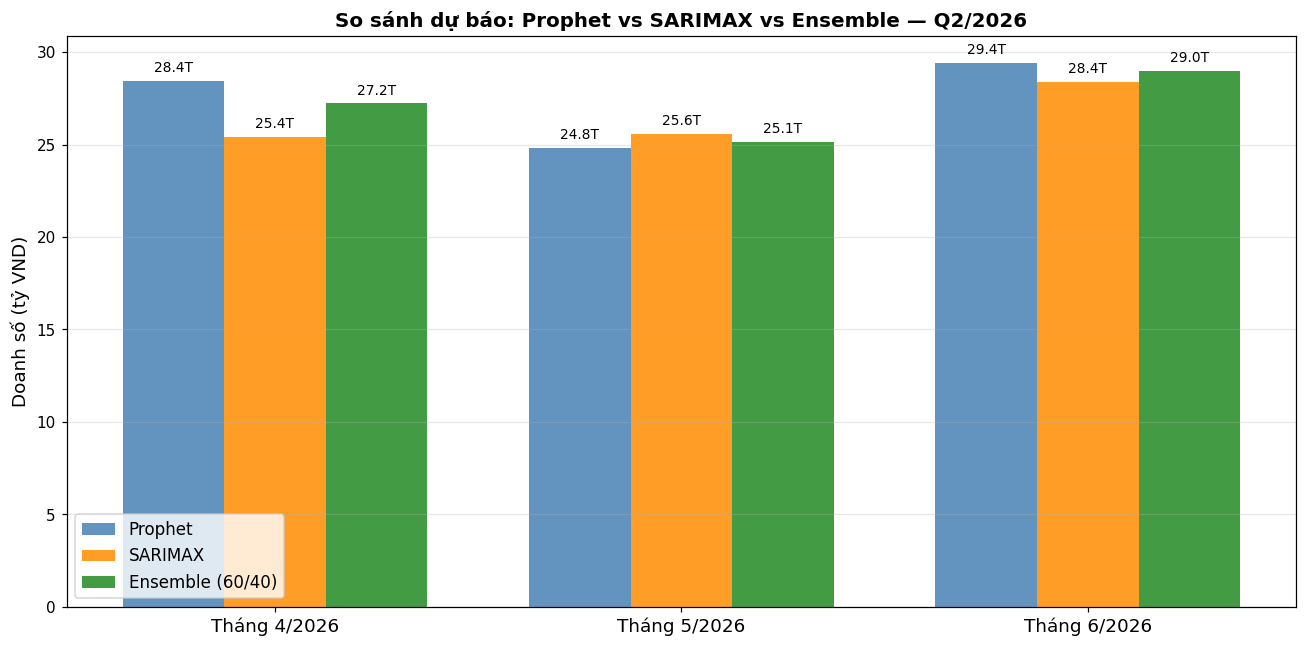

In [1]:
#so sánh Prophet vs SARIMAX
prophet_vals  = pd.read_csv('Ensemble/predictions_prophet.csv')['yhat'].values
sarimax_vals  = predictions_sarimax
ensemble_vals = 0.6*prophet_vals + 0.4*sarimax_vals
import numpy as np
x = np.arange(3)
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, prophet_vals/1e9,  width, label='Prophet', color='steelblue', alpha=0.85)
ax.bar(x,          sarimax_vals/1e9,  width, label='SARIMAX',  color='darkorange', alpha=0.85)
ax.bar(x + width,  ensemble_vals/1e9, width, label='Ensemble', color='forestgreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['T4/2026','T5/2026','T6/2026'])
ax.set_ylabel('Doanh số (tỷ VND)')
ax.set_title('So sánh: Prophet vs SARIMAX vs Ensemble Q2/2026', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show();

# Xuất kết quả

In [1]:
pred_df = pd.DataFrame({'ds': pd.date_range('2026-04-01', periods=3, freq='MS'),
                       'yhat': predictions_sarimax,
                       'yhat_lower': predictions_sarimax*0.9,
                       'yhat_upper': predictions_sarimax*1.1})
pred_df.to_csv('Ensemble/predictions_sarimax.csv', index=False)
print('✅ Đã lưu predictions_sarimax.csv')
pred_df

✅ Đã lưu predictions_sarimax.csv


ds,yhat
2026-04-01,25406576637
2026-05-01,25553379814
2026-06-01,28380993873
